In [15]:
import re
import os
import glob
from pathlib import Path
import pandas as pd

results_dir = Path('/Users/tatiana/Documents_new/visor_freqk/results')

# Var path structure (10 parts):
#   results/{sv_root}/{pos_label}/var/{cov_err}/{SV_TYPE}/{size}/{n_label}/{freq}/{k}/filename
#                                 ^^^
# We require 'var' to appear as a path component to select only variation-aware results.

all_files  = sorted(results_dir.rglob('*.allele_frequencies.k*.tsv'))
var_files  = [f for f in all_files
              if 'var' in f.relative_to(results_dir).parts]
skipped    = len(all_files) - len(var_files)

print(f"Total .tsv files found : {len(all_files)}")
print(f"Non-var (skipped)      : {skipped}")
print(f"Var (loaded)           : {len(var_files)}\n")

print(f"{'sv':3s}  {'pos':8s}  {'cov/err':12s}  {'SV':3s}  {'size':5s}  {'n':5s}  {'freq':4s}  {'k':4s}")
print("-" * 70)
for f in var_files:
    p = f.relative_to(results_dir).parts
    # p: sv_root / pos_label / 'var' / cov_err / SV_TYPE / size / n_label / freq / k / file
    print(f"{p[0]:3s}  {p[1]:8s}  {p[3]:12s}  {p[4]:3s}  {p[5]:5s}  {p[6]:5s}  {p[7]:4s}  {p[8]:4s}")

Total .tsv files found : 823
Non-var (skipped)      : 450
Var (loaded)           : 373

sv   pos       cov/err       SV   size   n      freq  k   
----------------------------------------------------------------------
del  pos10mb   cov10_err001  DEL  100bp  n231   f10   k31 
del  pos10mb   cov10_err001  DEL  100bp  n231   f30   k31 
del  pos10mb   cov10_err001  DEL  100bp  n231   f50   k31 
del  pos10mb   cov10_err001  DEL  100bp  n231   f70   k31 
del  pos10mb   cov10_err001  DEL  100bp  n231   f90   k31 
del  pos10mb   cov10_err001  DEL  10kb   n231   f10   k31 
del  pos10mb   cov10_err001  DEL  10kb   n231   f30   k31 
del  pos10mb   cov10_err001  DEL  10kb   n231   f50   k31 
del  pos10mb   cov10_err001  DEL  10kb   n231   f70   k31 
del  pos10mb   cov10_err001  DEL  10kb   n231   f90   k31 
del  pos10mb   cov10_err001  DEL  1kb    n231   f10   k31 
del  pos10mb   cov10_err001  DEL  1kb    n231   f30   k31 
del  pos10mb   cov10_err001  DEL  1kb    n231   f50   k31 
del  pos10mb   

In [16]:
len(var_files)

373

In [17]:
rows = []

for f in var_files:
    p = f.relative_to(results_dir).parts
    # Two possible var path structures:
    #
    # OLD (9 parts, no n_samples dir):
    #   sv / pos / 'var' / cov_err / SV_TYPE / size / freq / k / file
    #    0    1      2       3         4        5      6     7    8
    #
    # NEW (10 parts, with n_samples dir):
    #   sv / pos / 'var' / cov_err / SV_TYPE / size / n_lbl / freq / k / file
    #    0    1      2       3         4        5       6       7    8    9

    sv_root   = p[0]
    pos_label = p[1]
    cov_err   = p[3]
    sv_type   = p[4]
    size      = p[5]

    # Detect structure from p[6]: starts with 'n' → new, 'f' → old
    if p[6].startswith('n'):
        n_lbl    = p[6]
        freq_lbl = p[7]
        k_lbl    = p[8]
    else:
        n_lbl    = None   # unknown for old results
        freq_lbl = p[6]
        k_lbl    = p[7]

    # Parse coverage and error_rate
    cov_part, err_part = cov_err.split('_')
    coverage   = int(cov_part.replace('cov', ''))
    err_str    = err_part.replace('err', '')
    error_rate = 0.0 if err_str == '0' else float('0.' + err_str)

    # Parse n_samples
    n_samples = int(n_lbl.replace('n', '')) if n_lbl else None

    # Parse nominal frequency: f50 → 0.50
    freq_nominal = int(freq_lbl.replace('f', '')) / 100.0

    # Parse k
    k = int(k_lbl.replace('k', ''))

    # Read AF values (single line: 'af_ref|af_alt')
    line     = f.read_text().strip()
    af_parts = line.split('|')
    af_ref   = float(af_parts[0])
    af_alt   = float(af_parts[1]) if len(af_parts) > 1 else float('nan')

    rows.append({
        'sv_root'     : sv_root,
        'sv_type'     : sv_type,
        'pos_label'   : pos_label,
        'cov_err'     : cov_err,
        'coverage'    : coverage,
        'error_rate'  : error_rate,
        'size'        : size,
        'n_samples'   : n_samples,
        'freq_label'  : freq_lbl,
        'freq_nominal': freq_nominal,
        'k_label'     : k_lbl,
        'k'           : k,
        'file'        : str(f),
        'af_ref'      : af_ref,
        'af_alt'      : af_alt,
    })

results_df = pd.DataFrame(rows)

if results_df.empty:
    print("No var results found yet — rerun once pipeline completes.")
else:
    results_df["error"]     = results_df["af_alt"] - results_df["freq_nominal"]
    results_df["abs_error"] = results_df["error"].abs()
    results_df["rel_error"] = results_df["abs_error"] / results_df["freq_nominal"]

In [18]:
# ── Compute error metrics ──────────────────────────────────────────────────────
results_df["error"]     = results_df["af_alt"] - results_df["freq_nominal"]   # signed bias
results_df["abs_error"] = results_df["error"].abs()
results_df["rel_error"] = results_df["abs_error"] / results_df["freq_nominal"]

In [19]:
results_df.to_csv('/Users/tatiana/Documents_new/visor_freqk/summaries/results_var_mar17_poslabel.csv',index=False)

In [20]:
import pandas as pd
results_df = pd.read_csv('/Users/tatiana/Documents_new/visor_freqk/summaries/results_var_mar17_poslabel.csv')

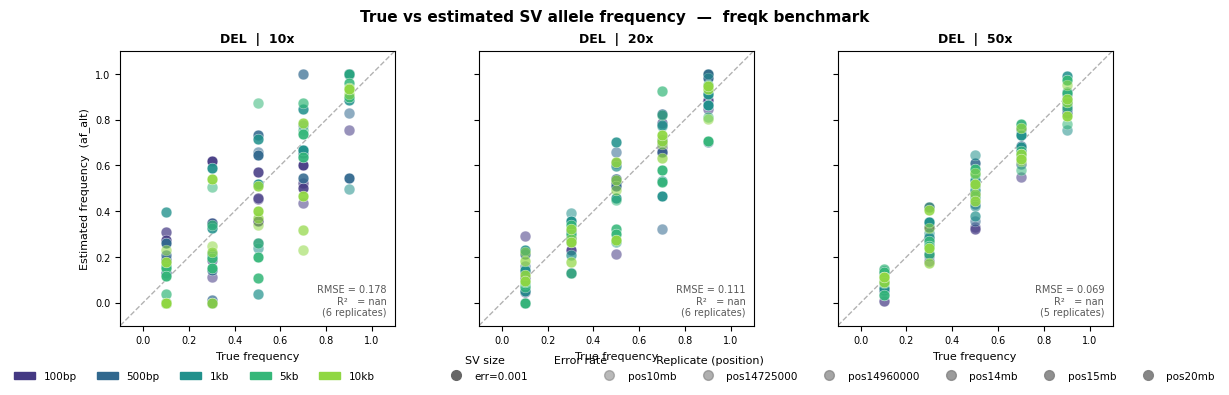

In [21]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from pathlib import Path

# ── Aesthetics ─────────────────────────────────────────────────────────────────
SIZE_ORDER  = ["100bp", "500bp", "1kb", "5kb", "10kb"]
palette     = sns.color_palette("viridis", len(SIZE_ORDER))
SIZE_COLORS = dict(zip(SIZE_ORDER, palette))

# Each error_rate gets a marker shape; positions (replicates) are individual dots
error_rates  = sorted(results_df["error_rate"].unique())
ERR_MARKERS  = dict(zip(error_rates, ["o", "s", "^", "D"]))

# Each replicate position gets an alpha level to make overlap visible
positions    = sorted(results_df["pos_label"].unique())
POS_ALPHA    = {p: a for p, a in zip(positions, np.linspace(0.55, 0.95, len(positions)))}

sv_types  = ["DEL"]
coverages = sorted(results_df["coverage"].unique())

# ── Layout: rows = sv_type, cols = coverage ────────────────────────────────────
nrows, ncols = len(sv_types), len(coverages)
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.6 * ncols, 3.6 * nrows),
    sharex=True, sharey=True,
    constrained_layout=True,
)
if nrows == 1: axes = [axes]
if ncols == 1: axes = [[ax] for ax in axes]

lo, hi = -0.1, 1.1

for i, svt in enumerate(sv_types):
    for j, cov in enumerate(coverages):
        ax = axes[i][j]
        subset = results_df[(results_df["sv_type"] == svt) & (results_df["coverage"] == cov)]

        # Plot every replicate position as a separate dot
        for err in error_rates:
            for size in SIZE_ORDER:
                for pos in positions:
                    pts = subset[
                        (subset["error_rate"] == err) &
                        (subset["size"]       == size) &
                        (subset["pos_label"]  == pos)
                    ]
                    if pts.empty:
                        continue
                    ax.scatter(
                        pts["freq_nominal"], pts["af_alt"],
                        color      = SIZE_COLORS.get(size, "grey"),
                        marker     = ERR_MARKERS.get(err, "x"),
                        alpha      = POS_ALPHA[pos],
                        s          = 60,
                        edgecolors = "white",
                        linewidths = 0.3,
                        zorder     = 3,
                    )

        # Identity line
        ax.plot([lo, hi], [lo, hi], color="black", lw=1, ls="--", alpha=0.3, zorder=1)

        # RMSE and R² over all replicates
        if not subset.empty:
            rmse  = np.sqrt(((subset["af_alt"] - subset["freq_nominal"]) ** 2).mean())
            r2    = np.corrcoef(subset["freq_nominal"], subset["af_alt"])[0, 1] ** 2
            n_rep = subset["pos_label"].nunique()
            ax.text(0.97, 0.03,
                    f"RMSE = {rmse:.3f}\nR²   = {r2:.3f}\n({n_rep} replicates)",
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=7, color="0.35",
                    bbox=dict(fc="white", ec="none", alpha=0.7, pad=1))

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        ax.set_title(f"{svt}  |  {cov}x", fontsize=9, fontweight="bold")
        if j == 0:
            ax.set_ylabel("Estimated frequency  (af_alt)", fontsize=8)
        if i == nrows - 1:
            ax.set_xlabel("True frequency", fontsize=8)
        ax.tick_params(labelsize=7)

# ── Legends ────────────────────────────────────────────────────────────────────
size_patches = [mpatches.Patch(color=SIZE_COLORS[s], label=s) for s in SIZE_ORDER]
err_handles  = [
    mlines.Line2D([], [], color="0.4", marker=ERR_MARKERS[e], linestyle="None",
                  markersize=7, label=f"err={e}")
    for e in error_rates
]
pos_handles  = [
    mlines.Line2D([], [], color="0.5", marker="o", linestyle="None",
                  markersize=7, alpha=POS_ALPHA[p], label=p)
    for p in positions
]

fig.legend(
    handles=size_patches
            + [mpatches.Patch(visible=False)]
            + err_handles
            + [mpatches.Patch(visible=False)]
            + pos_handles,
    title="SV size              Error rate              Replicate (position)",
    loc="lower center",
    ncol=len(SIZE_ORDER) + 1 + len(err_handles) + 1 + len(pos_handles),
    fontsize=7.5, title_fontsize=8,
    bbox_to_anchor=(0.5, -0.07),
    frameon=False,
)

fig.suptitle("True vs estimated SV allele frequency  —  freqk benchmark",
             fontsize=11, fontweight="bold")

Path("/Users/tatiana/Documents_new/visor_freqk/plots/").mkdir(exist_ok=True)
fig.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/true_vs_estimated_var.pdf", bbox_inches="tight")
fig.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/true_vs_estimated_var.png", bbox_inches="tight", dpi=150)
plt.show()


In [22]:
results_df['pos_label'].value_counts()

pos_label
pos10mb        77
pos14725000    75
pos15mb        75
pos20mb        75
pos14960000    65
pos14mb         6
Name: count, dtype: int64

In [23]:
results_df.groupby('pos_label')['abs_error'].mean()

pos_label
pos10mb        0.106273
pos14725000         NaN
pos14960000    0.098071
pos14mb        0.110928
pos15mb        0.080110
pos20mb        0.084465
Name: abs_error, dtype: float64

In [ ]:

from collections import Counter
from Bio import SeqIO

FASTA   = "/Users/tatiana/Documents_new/visor_freqk/data/reference/Chr1.fa"
K       = 31
WINDOW  = 10_000

def _parse_pos(label: str) -> int:
    label = label.replace("pos", "")
    if label.endswith("mb"):
        return int(label[:-2]) * 1_000_000
    return int(label)

# ── genome-wide repeat set ────────────────────────────────────────────────────
# A k-mer is in this set if it appears ≥2× anywhere in Chr1.
# This is what freqk uses: multi-copy k-mers are filtered, so windows with a
# high fraction of repeated k-mers will have few (or zero) usable k-mers.
def build_repeat_set(ref_seq: str, k: int = K) -> frozenset:
    seen_once = set()
    repeated  = set()
    seq_clean = ref_seq.replace("N", "")
    for i in range(len(seq_clean) - k + 1):
        km = seq_clean[i : i + k]
        if km in seen_once:
            repeated.add(km)
        else:
            seen_once.add(km)
    del seen_once
    return frozenset(repeated)

def global_repeat_score(seq: str, repeat_set: frozenset, k: int = K) -> float:
    """Fraction of k-mers in seq that appear ≥2× genome-wide."""
    seq = seq.replace("N", "")
    total = len(seq) - k + 1
    if total <= 0:
        return float("nan")
    n_rep = sum(1 for i in range(total) if seq[i : i + k] in repeat_set)
    return n_rep / total

print("Loading reference …", end=" ", flush=True)
ref_seq = str(next(SeqIO.parse(FASTA, "fasta")).seq).upper()
print(f"done  ({len(ref_seq):,} bp)")

print("Building genome-wide k-mer repeat set … (may take ~30 s)", end=" ", flush=True)
genome_repeat_set = build_repeat_set(ref_seq)
print(f"done  ({len(genome_repeat_set):,} multi-copy k-mers)")

unique_labels = results_df["pos_label"].unique()
pos_meta = {}
for lbl in sorted(unique_labels):
    pos = _parse_pos(lbl)
    rs  = global_repeat_score(ref_seq[pos : pos + WINDOW], genome_repeat_set)
    if   rs < 0.10: rtype = "low repeat"
    elif rs < 0.50: rtype = "moderate repeat"
    else:           rtype = "high repeat"
    pos_meta[lbl] = {"pos_bp": pos, "repeat_score": rs, "region_type": rtype}
    print(f"  {lbl:15s}  ({pos/1e6:7.3f} Mb)  global_repeat_score={rs:.3f}  → {rtype}")

results_df = results_df.copy()   # avoid SettingWithCopyWarning
results_df["pos_bp"]       = results_df["pos_label"].map(lambda l: pos_meta[l]["pos_bp"])
results_df["repeat_score"] = results_df["pos_label"].map(lambda l: pos_meta[l]["repeat_score"])
results_df["region_type"]  = results_df["pos_label"].map(lambda l: pos_meta[l]["region_type"])
results_df["detected"]     = results_df["af_alt"].notna()

print(f"\nDetection rate by repeat level:")
print(results_df.groupby("region_type")["detected"].mean().round(3).to_string())


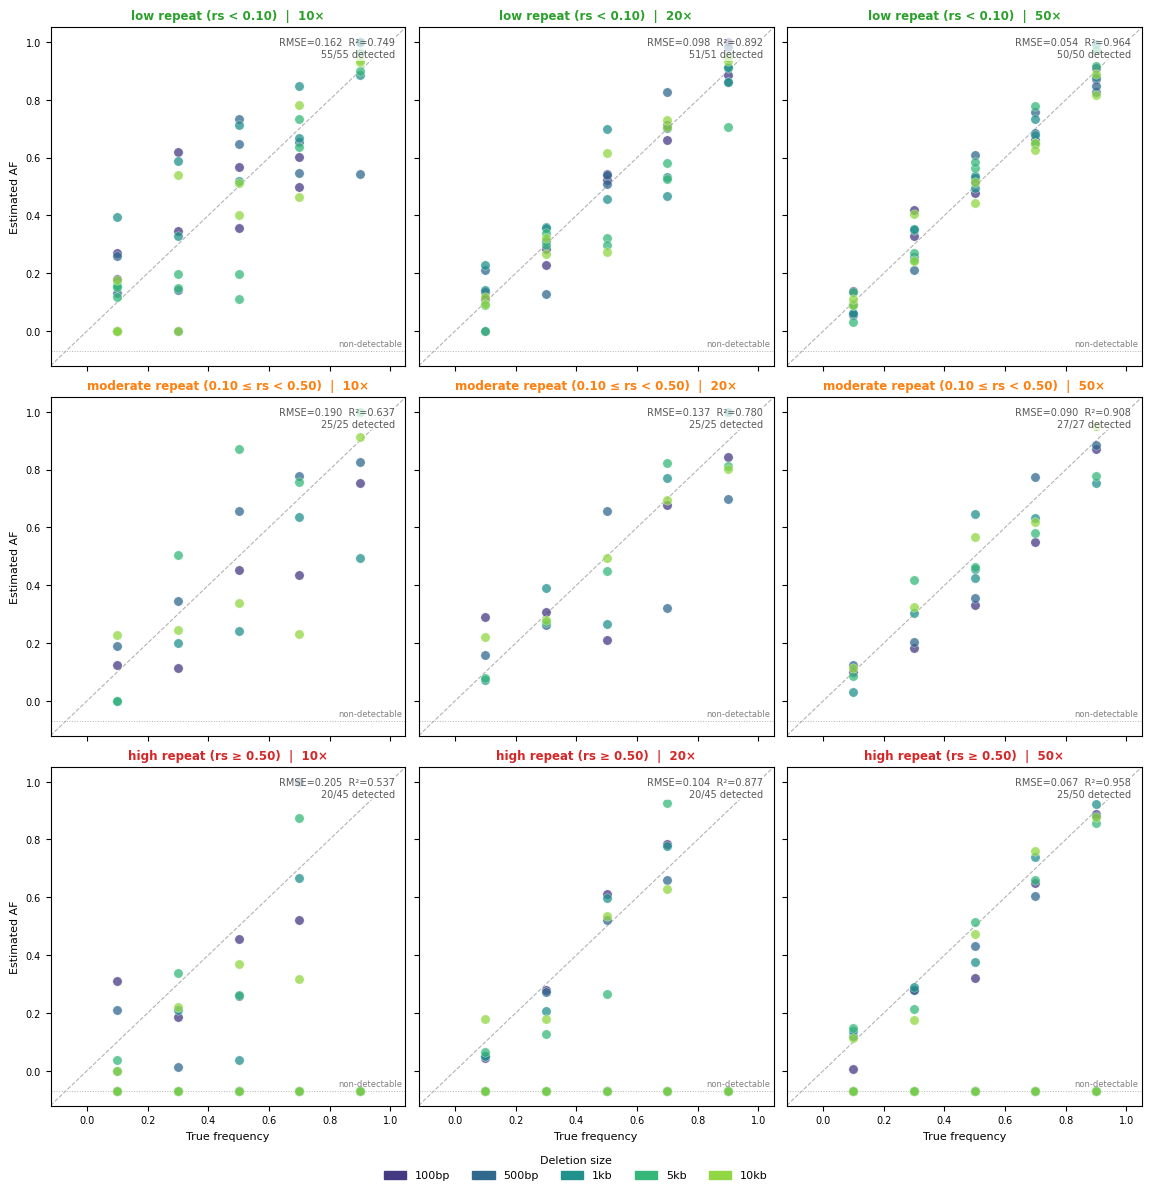

In [25]:

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from pathlib import Path

# ── Plot 2: True vs estimated AF, split by region type ───────────────────────
#
# Detected rows: scatter true vs estimated, coloured by deletion size
# Non-detected rows: circles at y = -0.07 ("non-detectable" band), same size colour
#
# Rows = region_type (low / moderate / high repeat)
# Cols = coverage

SIZE_ORDER   = ["100bp", "500bp", "1kb", "5kb", "10kb"]
palette      = sns.color_palette("viridis", len(SIZE_ORDER))
SIZE_COLORS  = dict(zip(SIZE_ORDER, palette))

REGION_ORDER  = ["low repeat", "moderate repeat", "high repeat"]
REGION_COLORS = {"low repeat": "#2ca02c", "moderate repeat": "#ff7f0e", "high repeat": "#d62728"}

# RS threshold labels shown in each panel title
REGION_RANGE = {
    "low repeat":      "rs < 0.10",
    "moderate repeat": "0.10 ≤ rs < 0.50",
    "high repeat":     "rs ≥ 0.50",
}

coverages = sorted(results_df["coverage"].unique())
nrows, ncols = len(REGION_ORDER), len(coverages)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 3.8 * nrows),
                         sharex=True, sharey=True, constrained_layout=True)

lo, hi = -0.12, 1.05
ND_Y   = -0.07

for i, rtype in enumerate(REGION_ORDER):
    for j, cov in enumerate(coverages):
        ax = axes[i][j]
        sub = results_df[(results_df["region_type"] == rtype) &
                         (results_df["coverage"]    == cov)]

        det_sub  = sub[sub["detected"]]
        ndet_sub = sub[~sub["detected"]]

        # ── detected: filled circles ───────────────────────────────────────
        for size in SIZE_ORDER:
            pts = det_sub[det_sub["size"] == size]
            if pts.empty: continue
            ax.scatter(pts["freq_nominal"], pts["af_alt"],
                       color=SIZE_COLORS[size], marker="o", s=45, alpha=0.75,
                       edgecolors="white", linewidths=0.3, zorder=3)

        # ── non-detected: circles at bottom band, same size colour ─────────
        for size in SIZE_ORDER:
            pts = ndet_sub[ndet_sub["size"] == size]
            if pts.empty: continue
            ax.scatter(pts["freq_nominal"], [ND_Y] * len(pts),
                       color=SIZE_COLORS[size], marker="o", s=45, alpha=0.75,
                       edgecolors="white", linewidths=0.3, zorder=3)

        # ── reference lines ────────────────────────────────────────────────
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.3, zorder=1)
        ax.axhline(ND_Y, color="0.7", lw=0.7, ls=":", zorder=1)
        ax.text(hi - 0.01, ND_Y + 0.01, "non-detectable",
                ha="right", va="bottom", fontsize=6, color="0.5")

        # ── stats (detected only) ──────────────────────────────────────────
        n_tot = len(sub); n_det = len(det_sub)
        if n_det >= 2:
            rmse = np.sqrt(((det_sub["af_alt"] - det_sub["freq_nominal"]) ** 2).mean())
            r2   = np.corrcoef(det_sub["freq_nominal"], det_sub["af_alt"])[0, 1] ** 2
            ax.text(0.97, 0.97,
                    f"RMSE={rmse:.3f}  R²={r2:.3f}\n{n_det}/{n_tot} detected",
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=7, color="0.35",
                    bbox=dict(fc="white", ec="none", alpha=0.7, pad=1))

        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        color = REGION_COLORS[rtype]
        ax.set_title(f"{rtype} ({REGION_RANGE[rtype]})  |  {cov}×",
                     fontsize=8.5, fontweight="bold", color=color)
        if j == 0:
            ax.set_ylabel("Estimated AF", fontsize=8)
        if i == nrows - 1:
            ax.set_xlabel("True frequency", fontsize=8)
        ax.tick_params(labelsize=7)

# ── legend ─────────────────────────────────────────────────────────────────
size_patches = [mpatches.Patch(color=SIZE_COLORS[s], label=s) for s in SIZE_ORDER]
fig.legend(handles=size_patches,
           title="Deletion size",
           loc="lower center", ncol=len(SIZE_ORDER),
           fontsize=8, title_fontsize=8,
           bbox_to_anchor=(0.5, -0.04), frameon=False)


plt.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/true_vs_est_by_region.pdf",
            bbox_inches="tight")
plt.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/true_vs_est_by_region.png",
            bbox_inches="tight", dpi=150)
plt.show()


In [26]:
results_df

,sv_root,sv_type,pos_label,cov_err,coverage,error_rate,size,n_samples,freq_label,freq_nominal,...,file,af_ref,af_alt,error,abs_error,rel_error,pos_bp,repeat_score,region_type,detected
0,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,231.0,f10,0.1,...,/Users/tatiana/Documents_new/visor_freqk/resul...,0.874735,0.125265,0.025265,0.025265,0.252654,10000000,0.159178,moderate repeat,True
1,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,231.0,f30,0.3,...,/Users/tatiana/Documents_new/visor_freqk/resul...,0.886893,0.113107,-0.186893,0.186893,0.622978,10000000,0.159178,moderate repeat,True
2,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,231.0,f50,0.5,...,/Users/tatiana/Documents_new/visor_freqk/resul...,0.548766,0.451234,-0.048766,0.048766,0.097532,10000000,0.159178,moderate repeat,True
3,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,231.0,f70,0.7,...,/Users/tatiana/Documents_new/visor_freqk/resul...,0.565931,0.434069,-0.265931,0.265931,0.379901,10000000,0.159178,moderate repeat,True
4,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,231.0,f90,0.9,...,/Users/tatiana/Documents_new/visor_freqk/resul...,0.244651,0.755349,-0.144651,0.144651,0.160723,10000000,0.159178,moderate repeat,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,del,DEL,pos20mb,cov50_err001,50,0.001,5kb,231.0,f10,0.1,...,/Users/tatiana/Documents_new/visor_freqk/resul...,0.865512,0.134488,0.034488,0.034488,0.344878,20000000,0.033501,low repeat,True
369,del,DEL,pos20mb,cov50_err001,50,0.001,5kb,231.0,f30,0.3,...,/Users/tatiana/Documents_new/visor_freqk/resul...,0.753023,0.246977,-0.053023,0.053023,0.176743,20000000,0.033501,low repeat,True
370,del,DEL,pos20mb,cov50_err001,50,0.001,5kb,231.0,f50,0.5,...,/Users/tatiana/Documents_new/visor_freqk/resul...,0.414740,0.585260,0.085260,0.085260,0.170521,20000000,0.033501,low repeat,True
371,del,DEL,pos20mb,cov50_err001,50,0.001,5kb,231.0,f70,0.7,...,/Users/tatiana/Documents_new/visor_freqk/resul...,0.351175,0.648825,-0.051175,0.051175,0.073107,20000000,0.033501,low repeat,True


In [ ]:

# ── Plot: Effect of SV size on AF estimation  (coverage = 20×) ───────────────
#
# One panel per SV size (100bp → 10kb)
# x = true AF (freq_nominal), y = estimated AF (af_alt)
# Colour = repeat level (sequential light→dark blue as global repeat increases)
# All points: filled circles
#   · Detected:     on the scatter field
#   · Non-detected: circles in the "non-detectable" band at y = -0.07
#
# Requires genome_repeat_set and ref_seq in scope from the enrichment cell above.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from Bio import SeqIO

TARGET_COV = 20

df = pd.read_csv("/Users/tatiana/Documents_new/visor_freqk/summaries/results_var_mar17_poslabel.csv")
df = df[df["coverage"] == TARGET_COV].copy()
df["detected"] = df["af_alt"].notna()

def _parse_pos(label: str) -> int:
    label = label.replace("pos", "")
    return int(label[:-2]) * 1_000_000 if label.endswith("mb") else int(label)

pos_scores = {
    lbl: global_repeat_score(ref_seq[_parse_pos(lbl) : _parse_pos(lbl) + 10_000],
                             genome_repeat_set)
    for lbl in df["pos_label"].unique()
}

def rtype(rs):
    if np.isnan(rs):  return "high repeat"
    if rs < 0.10:     return "low repeat"
    if rs < 0.50:     return "moderate repeat"
    return "high repeat"

df["repeat_score"] = df["pos_label"].map(pos_scores)
df["region_type"]  = df["repeat_score"].map(rtype)

# Sequential blue palette: light → dark as global repeat level increases
REGION_ORDER  = ["low repeat", "moderate repeat", "high repeat"]
REGION_COLORS = {"low repeat": "#9ecae1", "moderate repeat": "#3182bd", "high repeat": "#08306b"}

REGION_RANGE = {
    "low repeat":      "rs < 0.10",
    "moderate repeat": "0.10 ≤ rs < 0.50",
    "high repeat":     "rs ≥ 0.50",
}

SIZE_ORDER = ["100bp", "500bp", "1kb", "5kb", "10kb"]
ncols = len(SIZE_ORDER)
fig, axes = plt.subplots(1, ncols, figsize=(3.8 * ncols, 4.2),
                         sharex=True, sharey=True, constrained_layout=True)

lo, hi = -0.12, 1.05
ND_Y = -0.07

for ax, size in zip(axes, SIZE_ORDER):
    sub  = df[df["size"] == size]
    det  = sub[sub["detected"]]
    ndet = sub[~sub["detected"]]

    for rg in REGION_ORDER:
        c = REGION_COLORS[rg]
        pts = det[det["region_type"] == rg]
        if not pts.empty:
            ax.scatter(pts["freq_nominal"], pts["af_alt"],
                       color=c, marker="o", s=55, alpha=0.85,
                       edgecolors="white", linewidths=0.3, zorder=3)
        pts = ndet[ndet["region_type"] == rg]
        if not pts.empty:
            ax.scatter(pts["freq_nominal"], [ND_Y] * len(pts),
                       color=c, marker="o", s=55, alpha=0.85,
                       edgecolors="white", linewidths=0.3, zorder=3)

    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.3, zorder=1)
    ax.axhline(ND_Y, color="0.7", lw=0.7, ls=":", zorder=1)
    ax.text(hi - 0.02, ND_Y + 0.01, "non-detectable",
            ha="right", va="bottom", fontsize=6, color="0.5")

    if len(det) >= 2:
        rmse = np.sqrt(((det["af_alt"] - det["freq_nominal"]) ** 2).mean())
        r2   = np.corrcoef(det["freq_nominal"], det["af_alt"])[0, 1] ** 2
        n_det, n_tot = len(det), len(sub)
        ax.text(0.97, 0.97,
                f"RMSE={rmse:.3f}  R²={r2:.3f}\n{n_det}/{n_tot} detected",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=7, color="0.35",
                bbox=dict(fc="white", ec="none", alpha=0.7, pad=1))

    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(f"del {size}", fontsize=10, fontweight="bold")
    ax.set_xlabel("True AF", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel("Estimated AF", fontsize=8)

legend_handles = [
    mpatches.Patch(color=REGION_COLORS[rg],
                   label=f"{rg}  ({REGION_RANGE[rg]})")
    for rg in REGION_ORDER
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=8, bbox_to_anchor=(0.5, -0.07), frameon=False)

fig.suptitle(f"Effect of SV size on AF estimation  —  {TARGET_COV}× coverage\n"
             "(colour = global repeat score: fraction of k-mers multi-copy in Chr1)",
             fontsize=11, fontweight="bold")

import os; os.makedirs("/Users/tatiana/Documents_new/visor_freqk/plots", exist_ok=True)
plt.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/sv_size_effect_cov20.pdf",
            bbox_inches="tight")
plt.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/sv_size_effect_cov20.png",
            bbox_inches="tight", dpi=150)
plt.show()


In [28]:
results_df['pos_label'].unique()

array(['pos10mb', 'pos14725000', 'pos14960000', 'pos14mb', 'pos15mb',
       'pos20mb'], dtype=object)

In [29]:
results_df[results_df['pos_label'] == 'pos14725000'].dropna()

,sv_root,sv_type,pos_label,cov_err,coverage,error_rate,size,n_samples,freq_label,freq_nominal,...,file,af_ref,af_alt,error,abs_error,rel_error,pos_bp,repeat_score,region_type,detected
